# Maps: levels and changes
This notebook visualizes spatial patterns for levels and quinquennial
changes of key indicators.

In [1]:
from __future__ import annotations

import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.maps import load_world_geometries, merge_world_data, plot_choropleth
from src.paths import CLEAN_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS
from src.viz_style import savefig, set_style

In [2]:
set_style()
panel_path = CLEAN_DIR / "panel_quinquennial_atlas.parquet"
if not panel_path.exists():
    raise FileNotFoundError("Missing atlas panel. Run 03_build_quinquennial_panel first.")

panel = pd.read_parquet(panel_path)
world = load_world_geometries()

,stat,efw_summary,log_gdp_pc_const,trade_open_gdp
0,mean,6.580303,8.757146,78.405722
1,std,0.987532,1.378394,53.050098
2,min,2.980000,5.573916,9.955145
3,max,8.640000,11.990791,375.581396


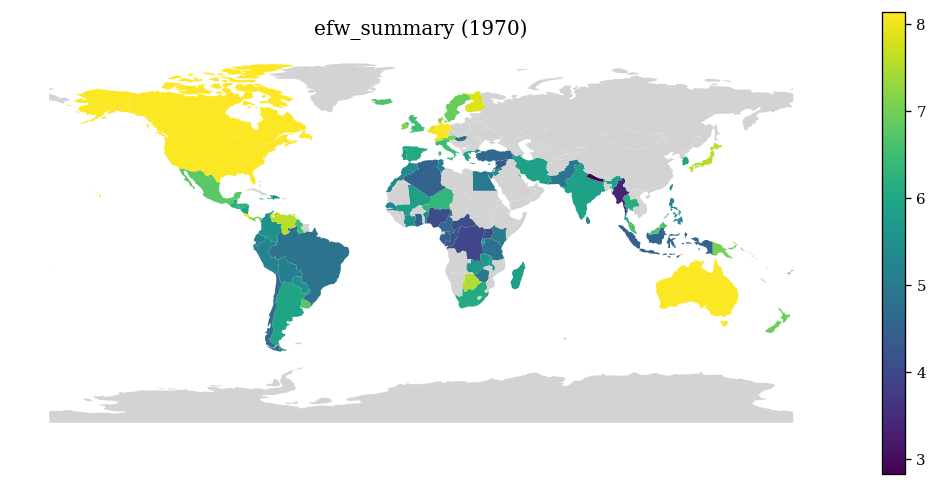

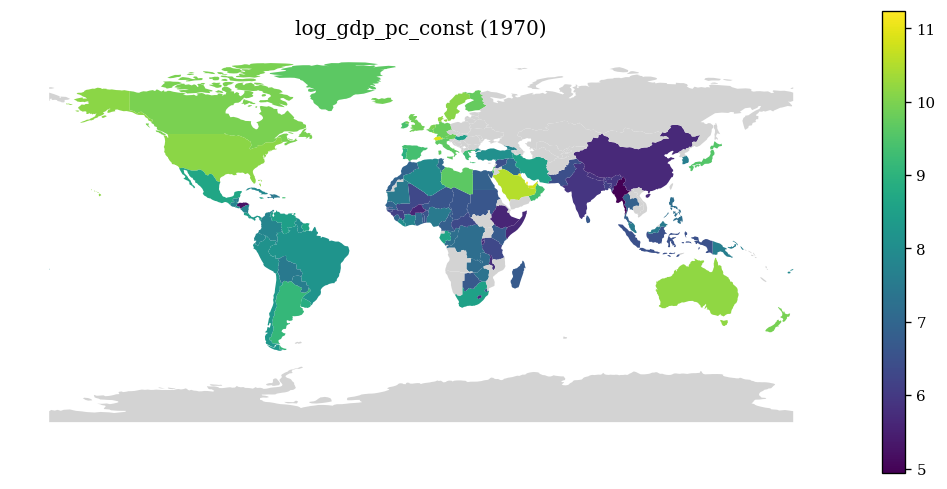

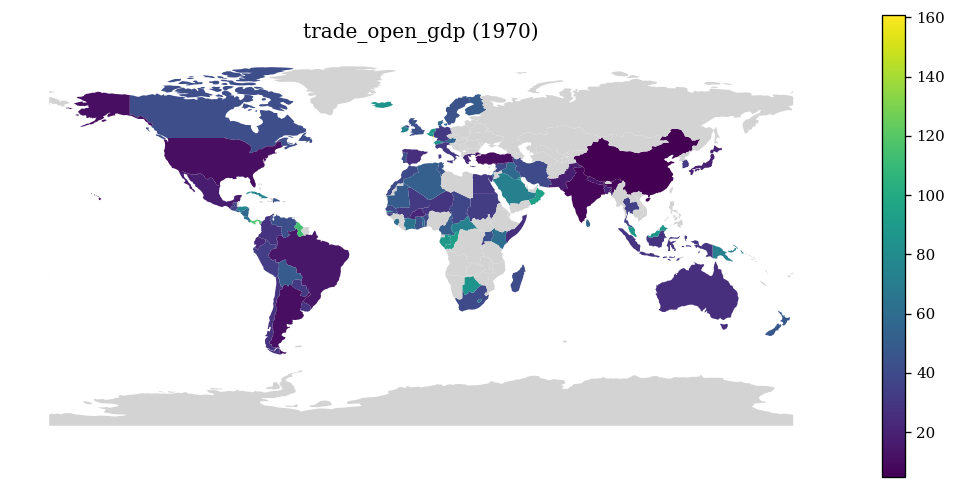

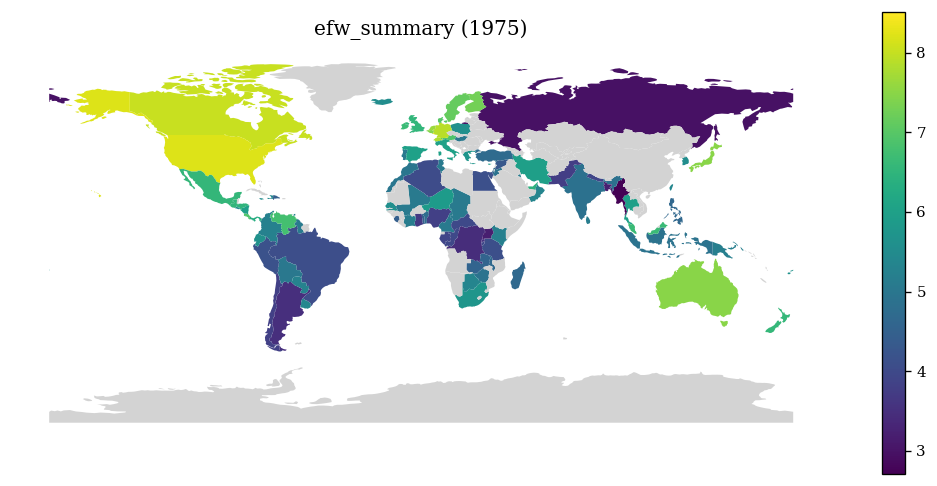

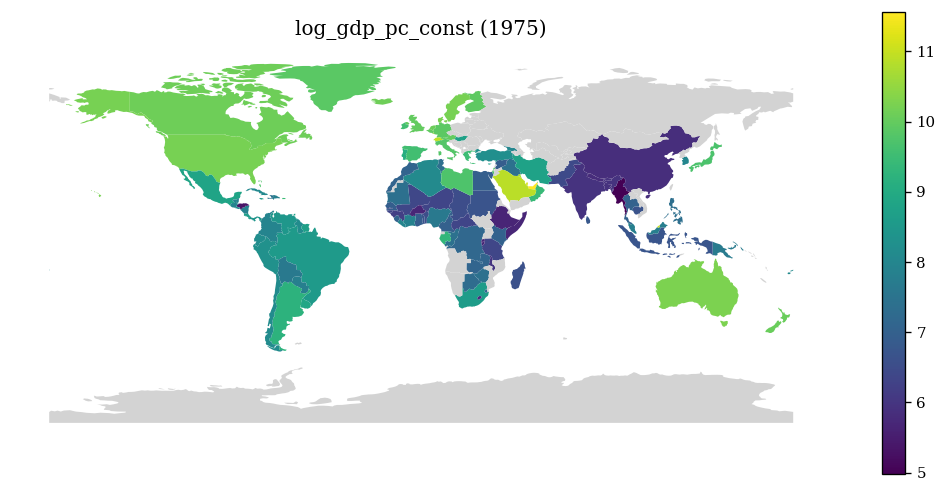

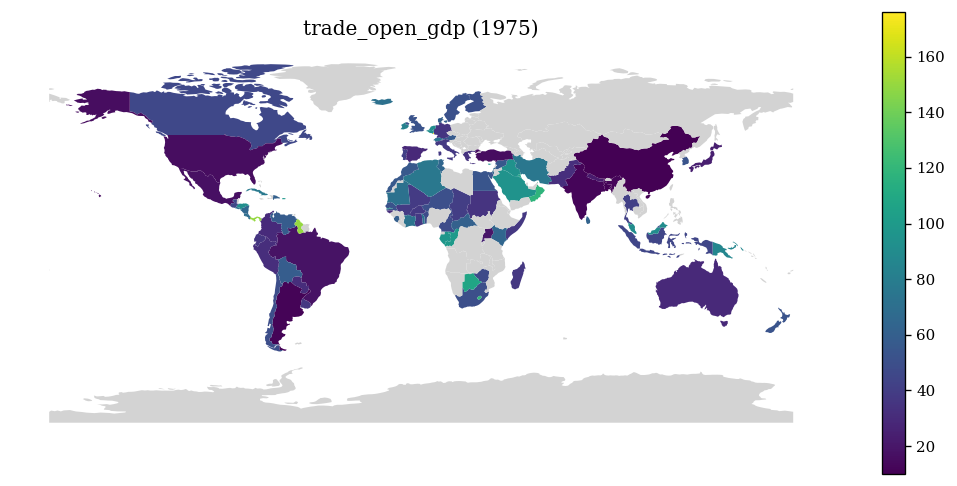

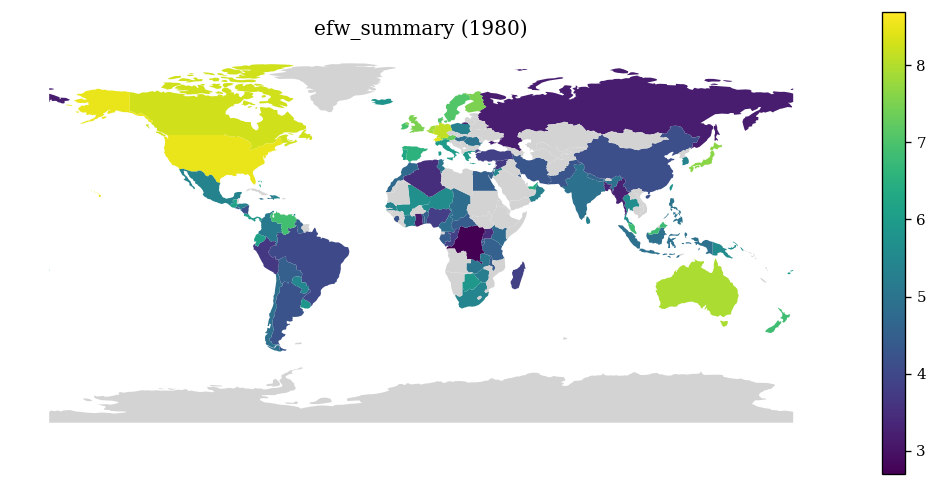

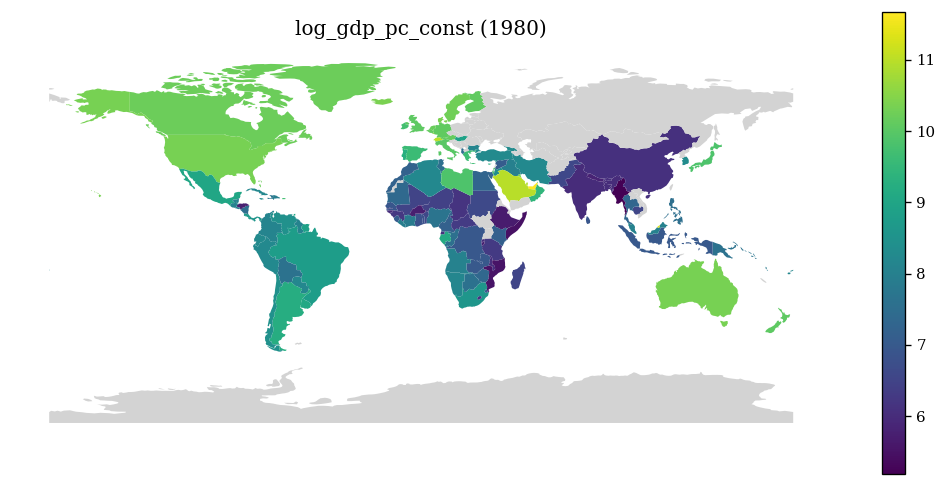

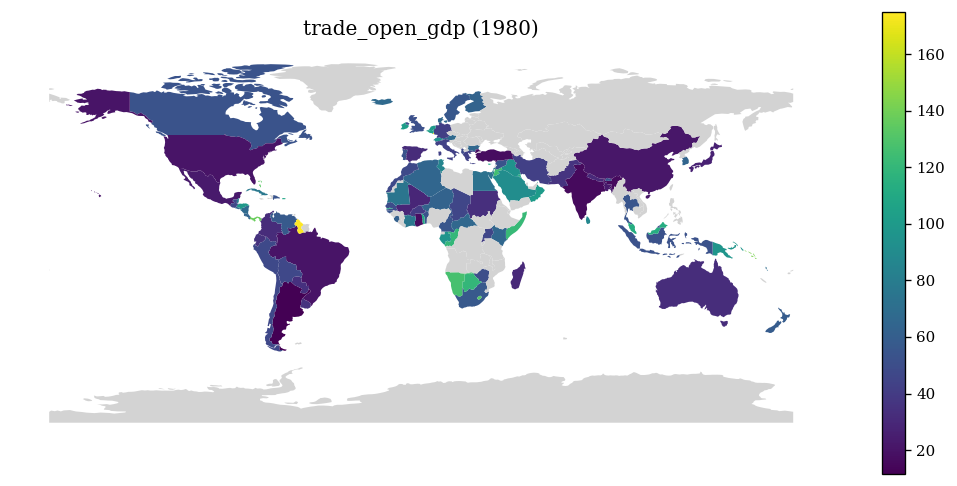

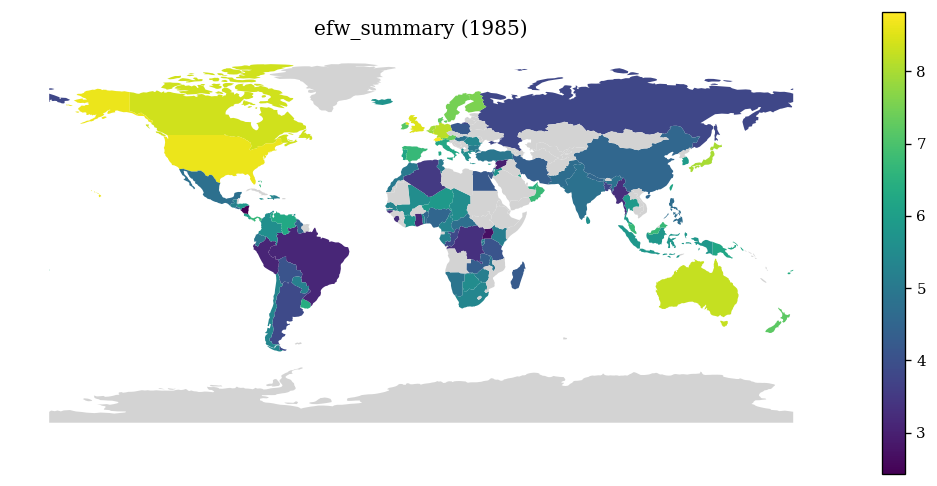

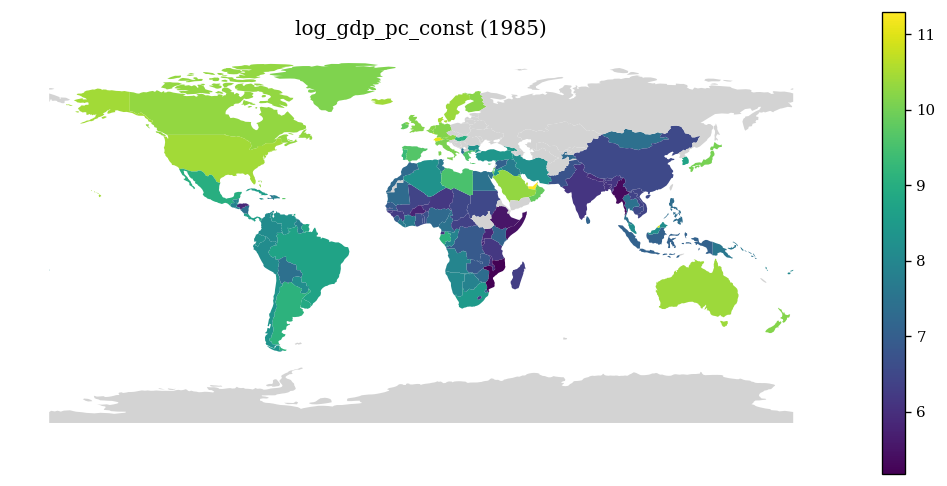

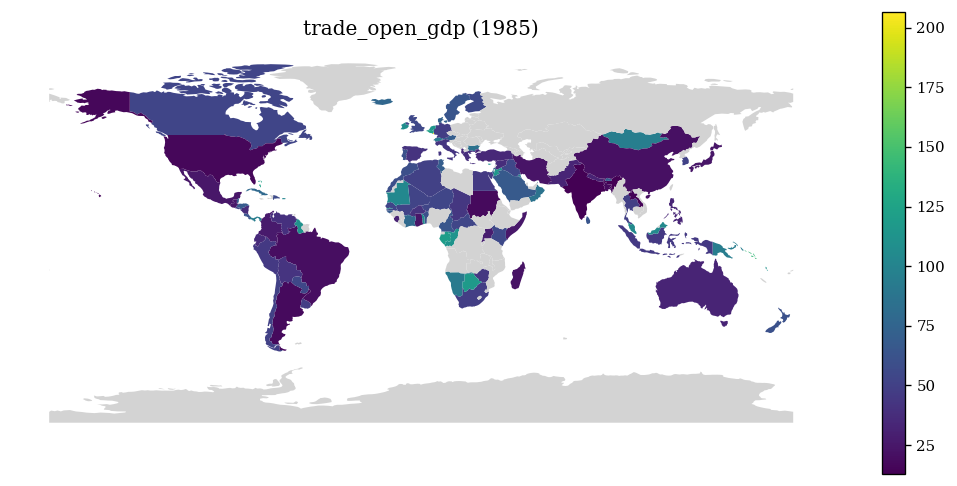

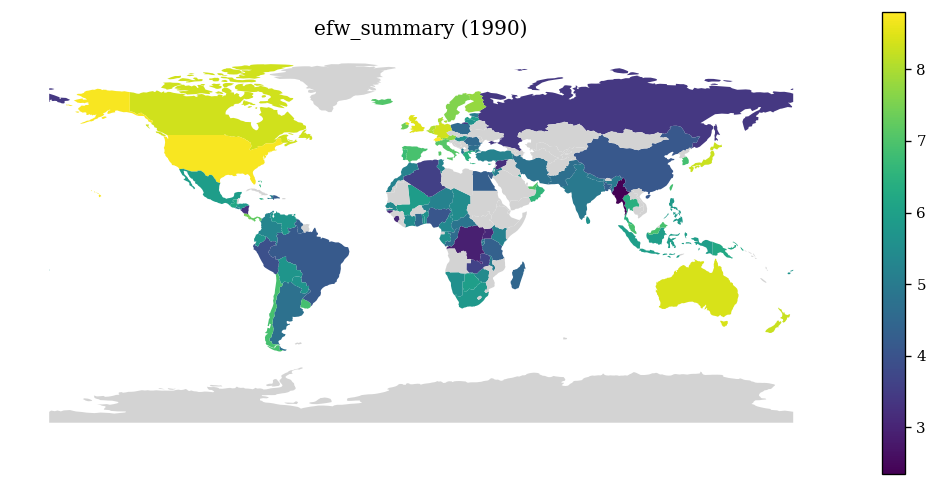

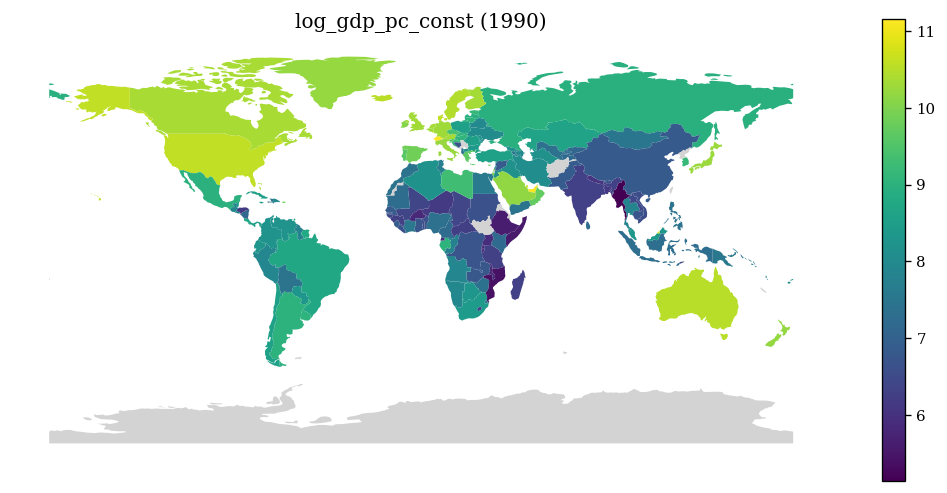

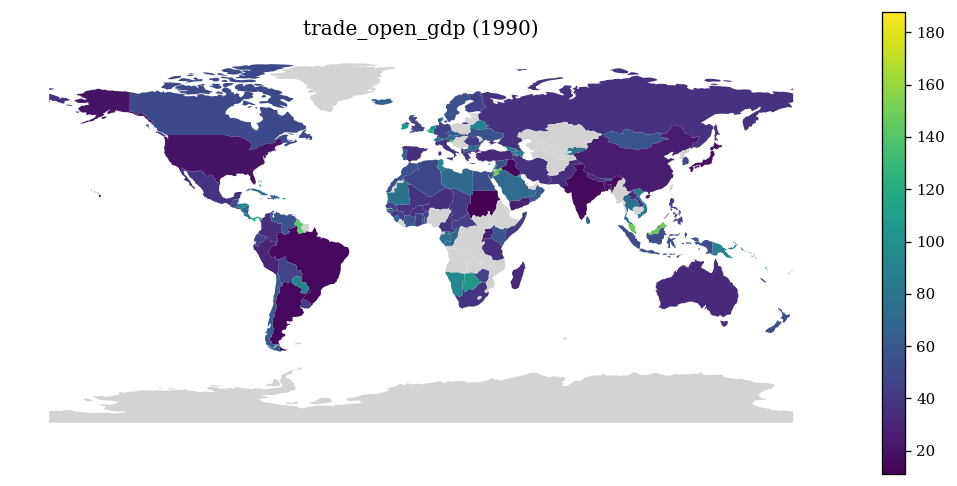

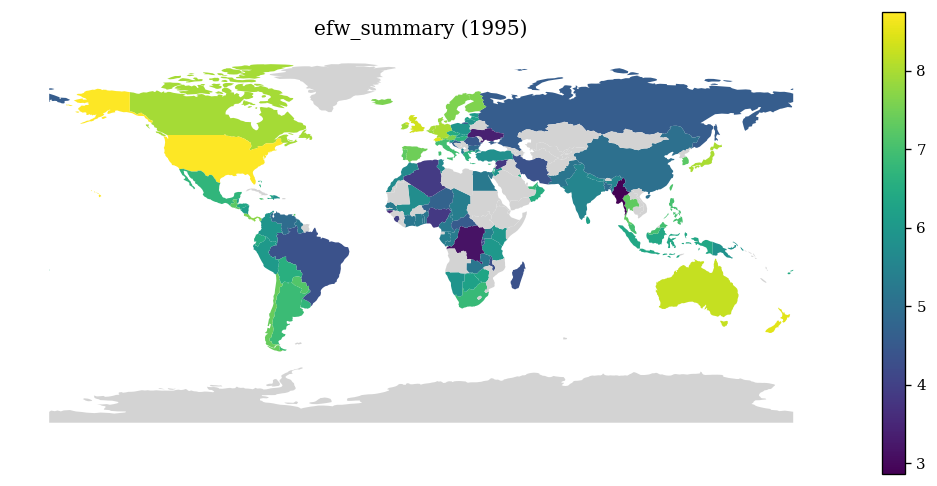

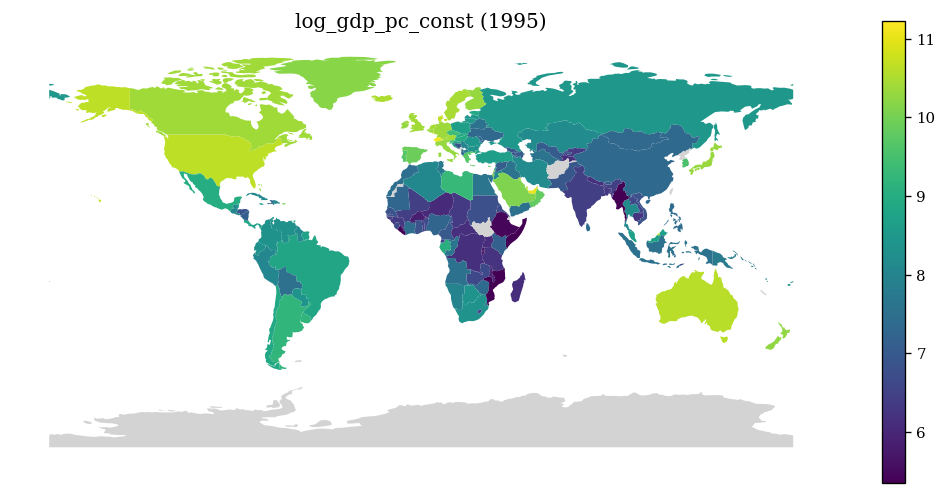

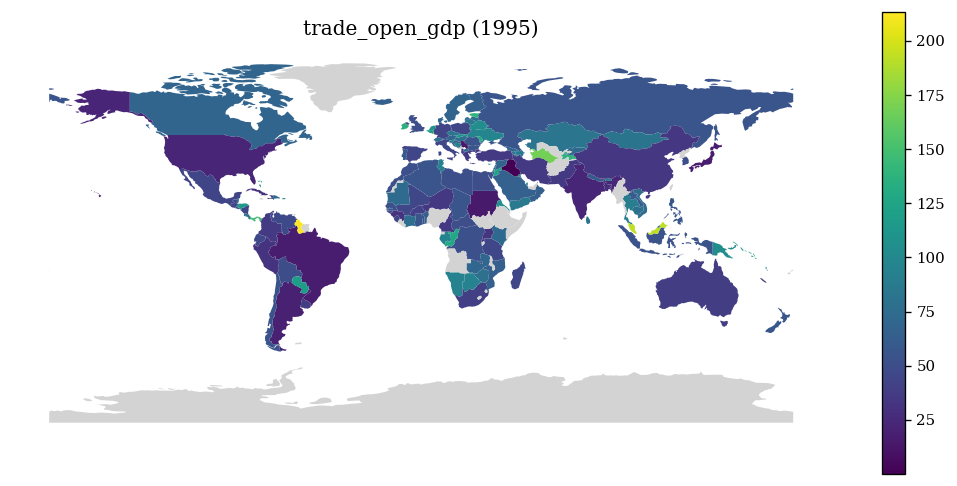

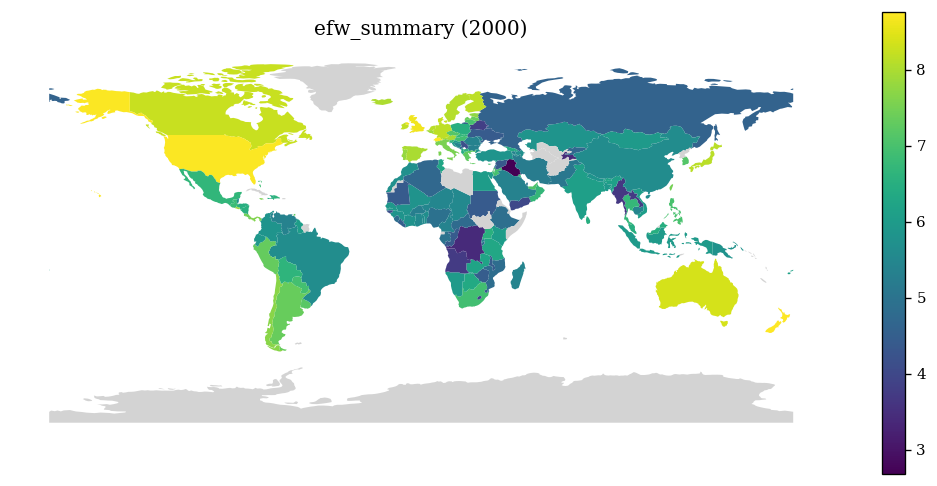

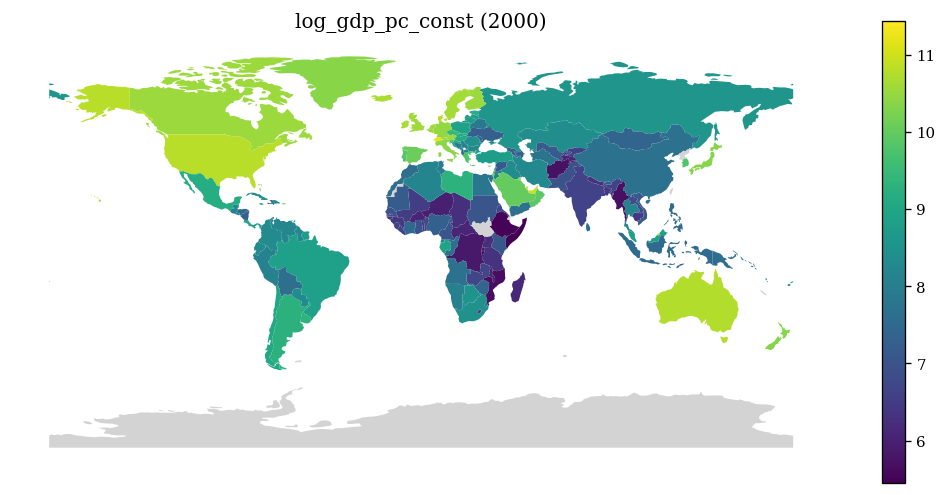

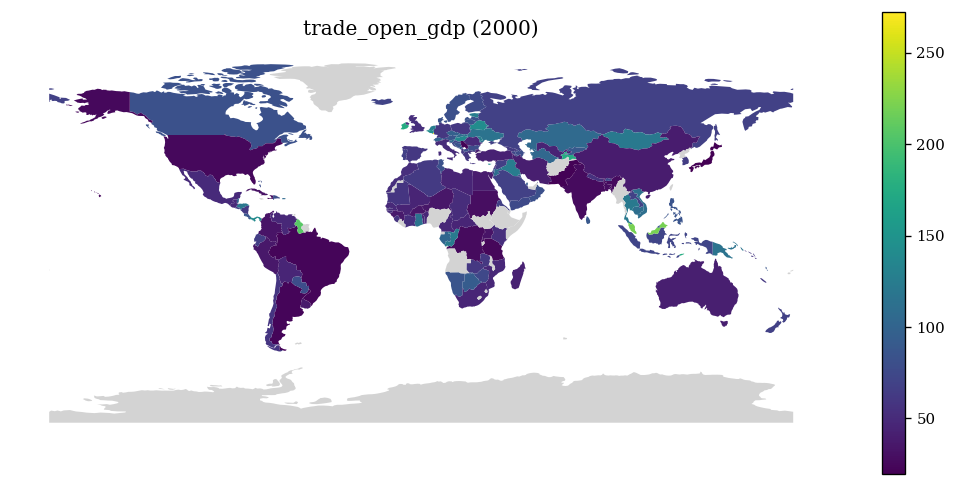

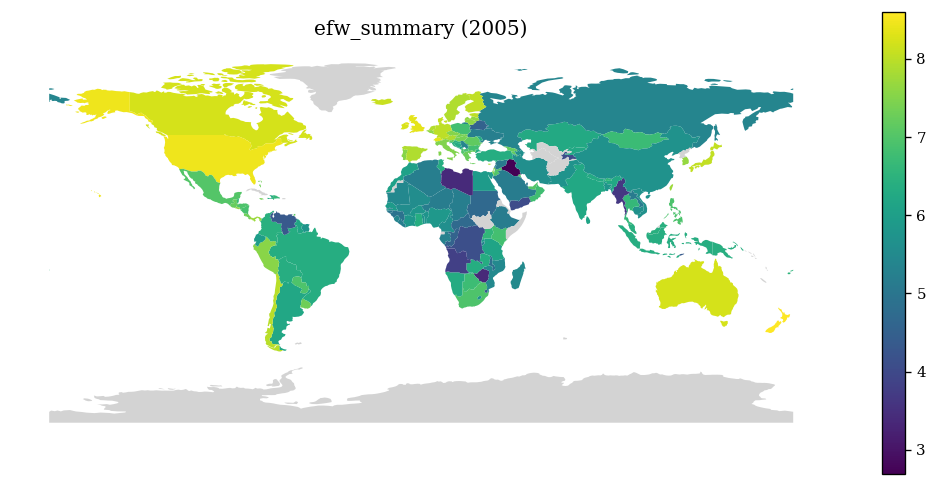

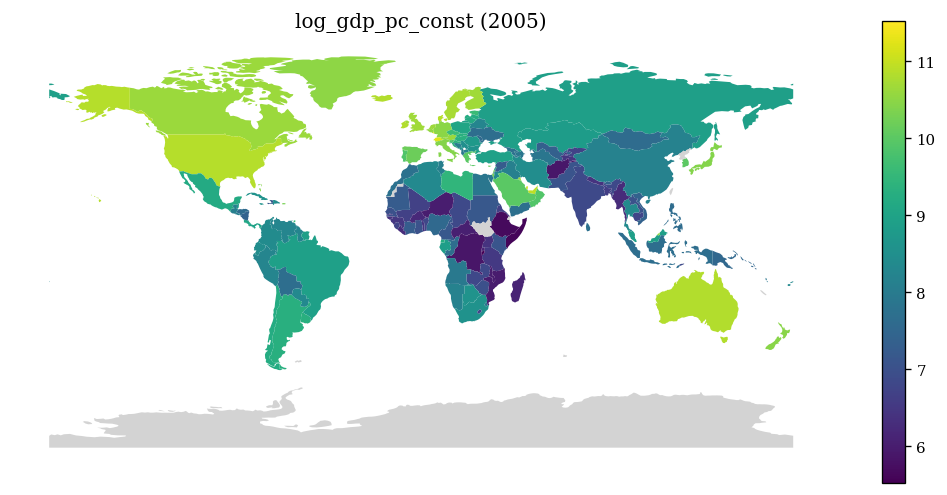

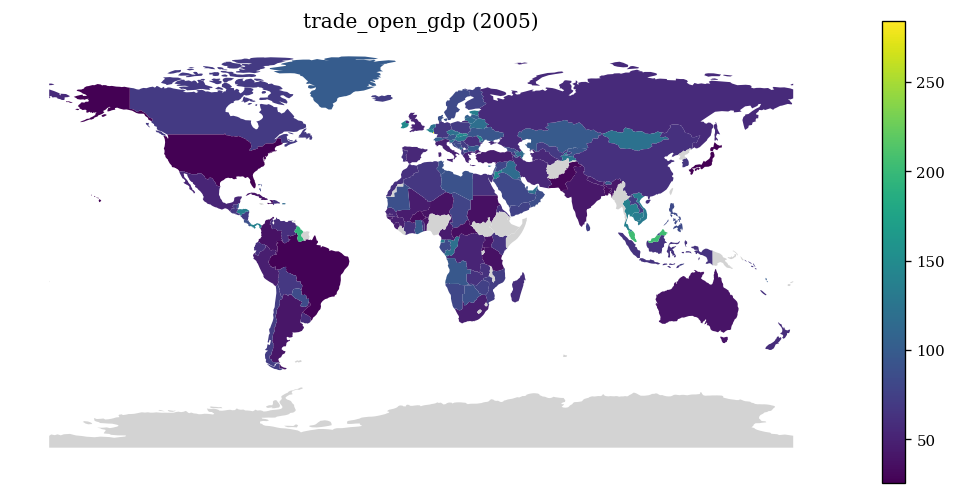

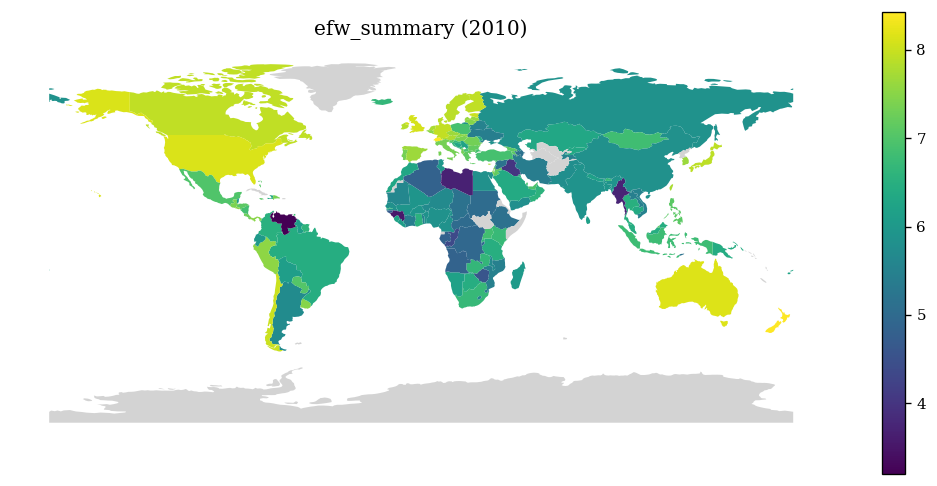

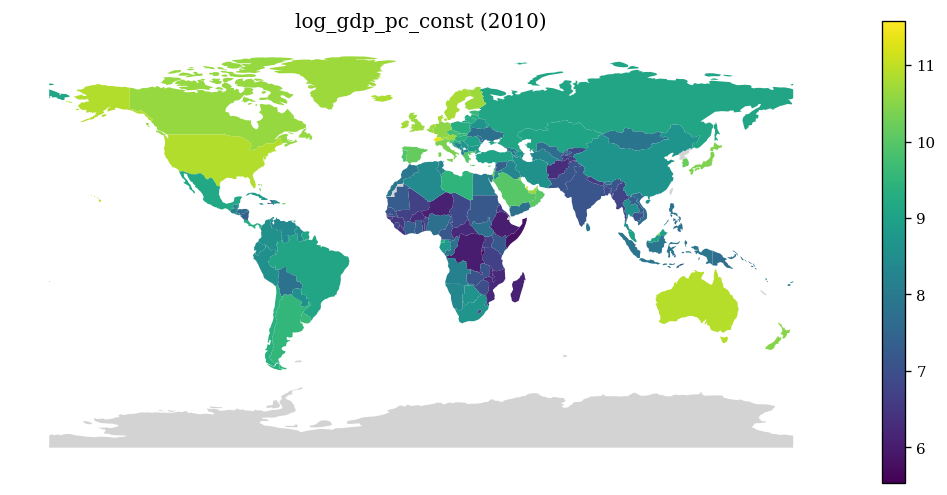

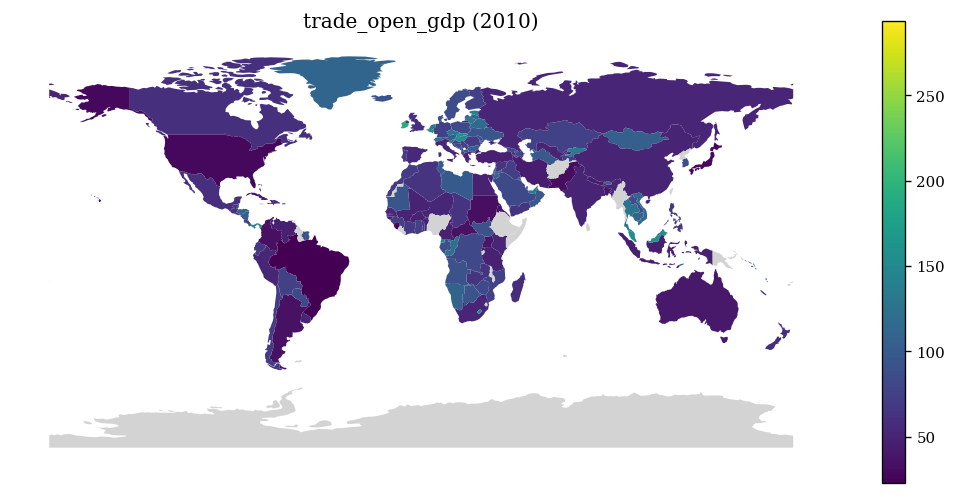

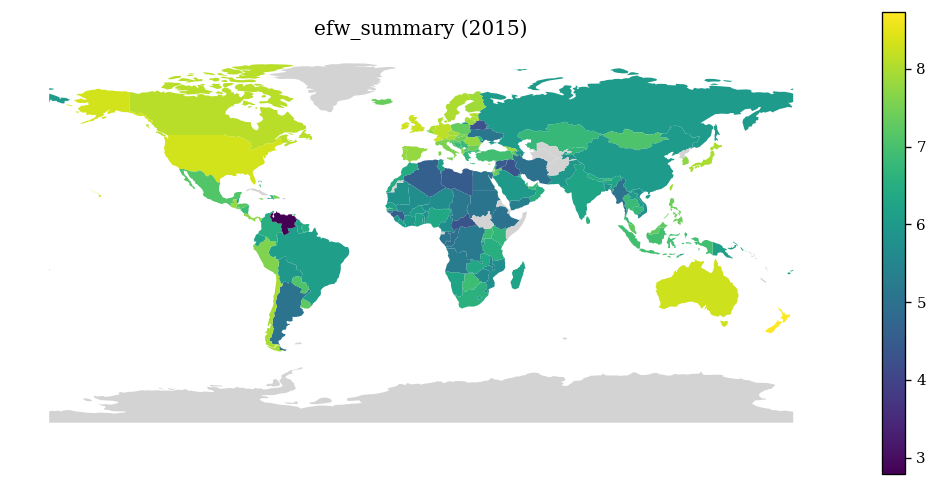

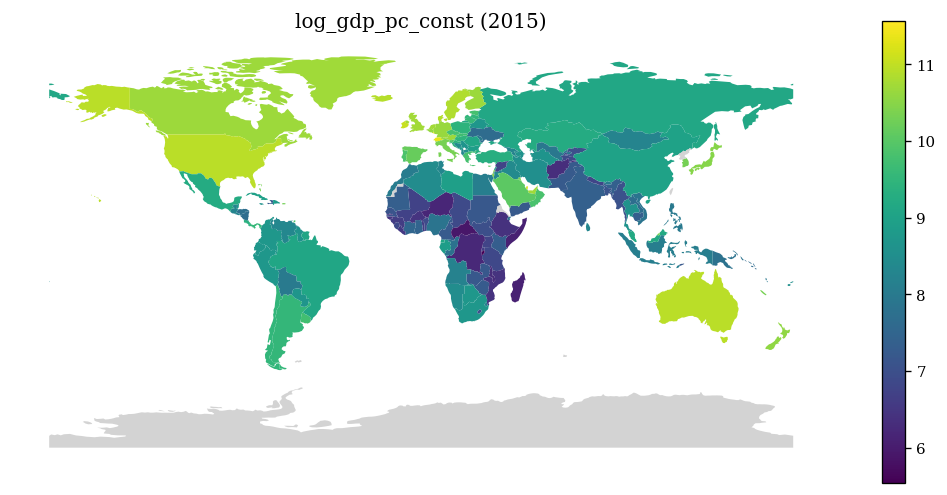

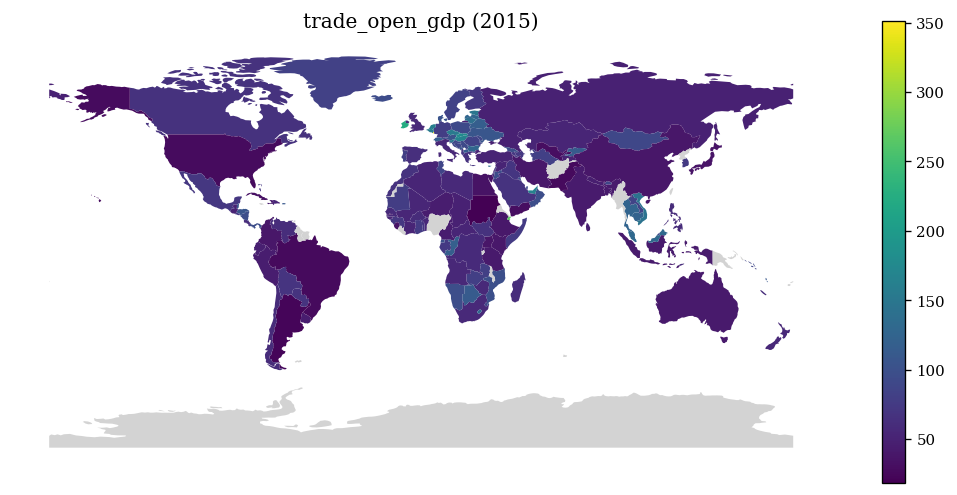

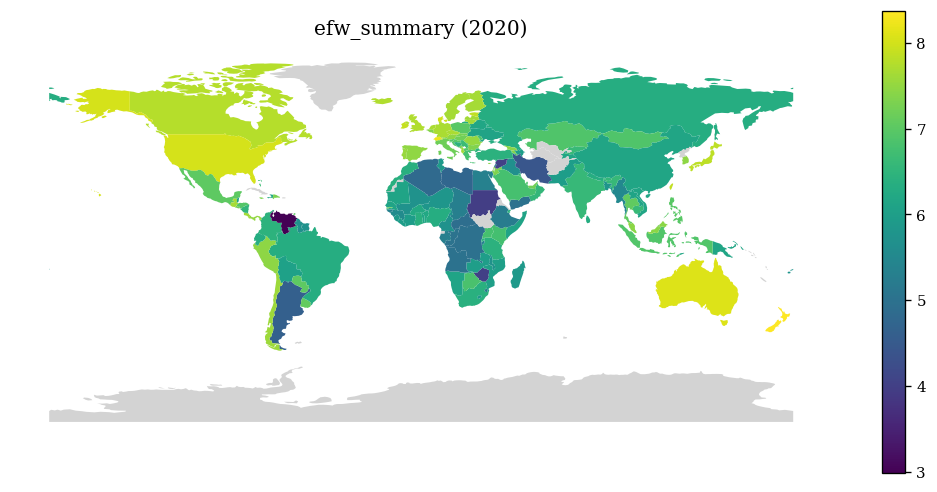

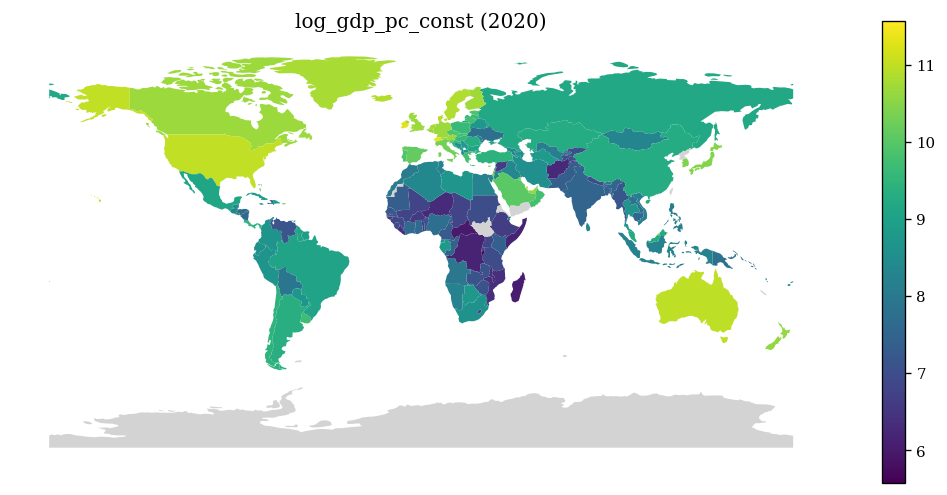

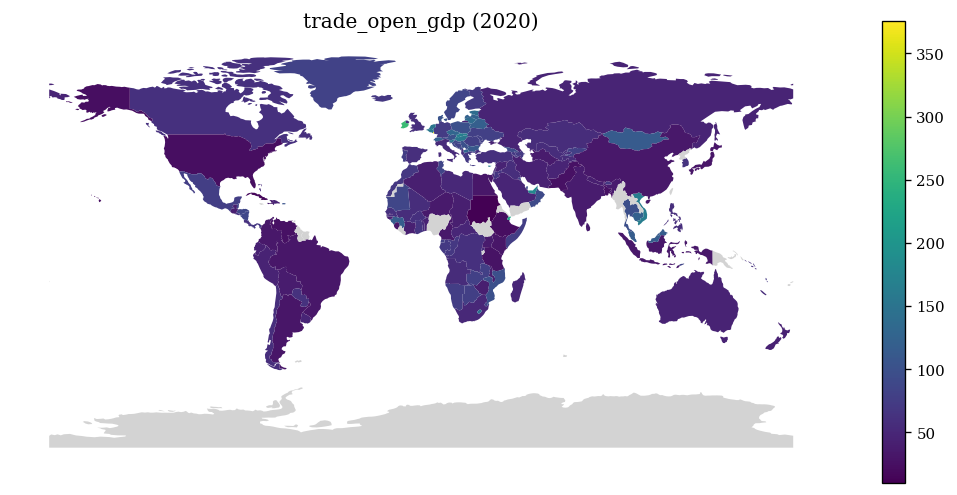

In [3]:
level_vars = ["efw_summary", "log_gdp_pc_const", "trade_open_gdp"]
level_vars = [var for var in level_vars if var in panel.columns]

map_dir = OUTPUT_DIR / "figures" / "maps"
map_dir.mkdir(parents=True, exist_ok=True)

latest_year = QUINQUENNIAL_YEARS[-1]
if level_vars:
    level_summary = (
        panel[panel["year"] == latest_year][level_vars]
        .describe()
        .loc[["mean", "std", "min", "max"]]
        .reset_index()
        .rename(columns={"index": "stat"})
    )
    display(level_summary.style.set_caption(f"Level summaries, {latest_year}"))

for year in QUINQUENNIAL_YEARS:
    subset = panel[panel["year"] == year]
    for var in level_vars:
        merged = merge_world_data(world, subset, "iso3c", var)
        fig, _ = plot_choropleth(
            merged,
            var,
            title=f"{var} ({year})",
            cmap="viridis",
            missing_color="lightgrey",
        )
        display(fig)
        savefig(fig, map_dir / f"levels_{var}_{year}")
        plt.close(fig)

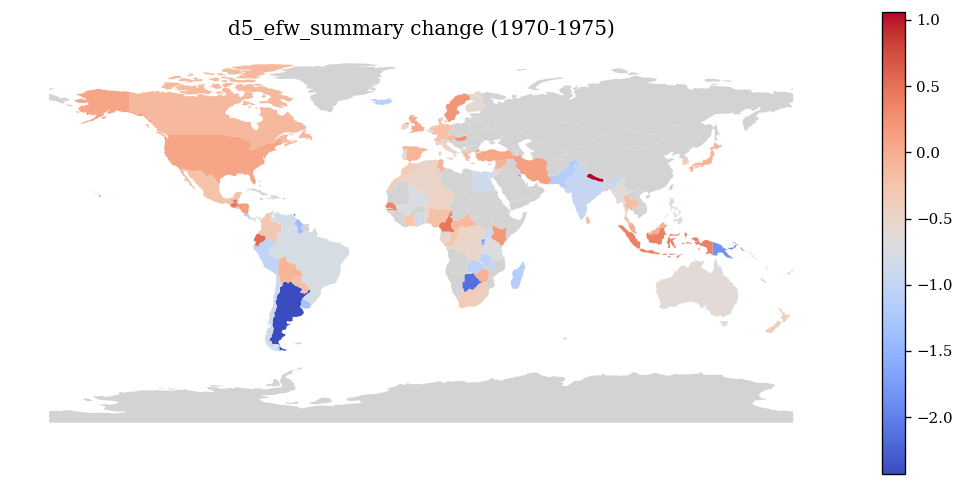

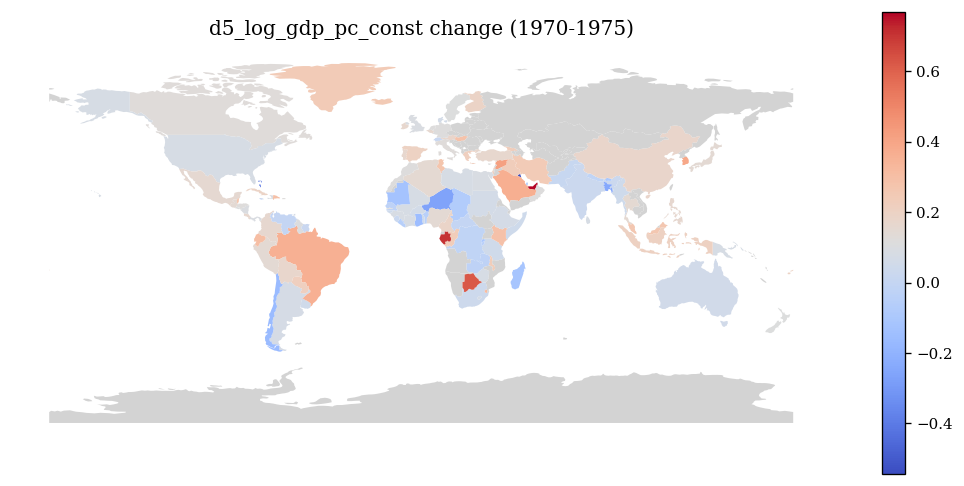

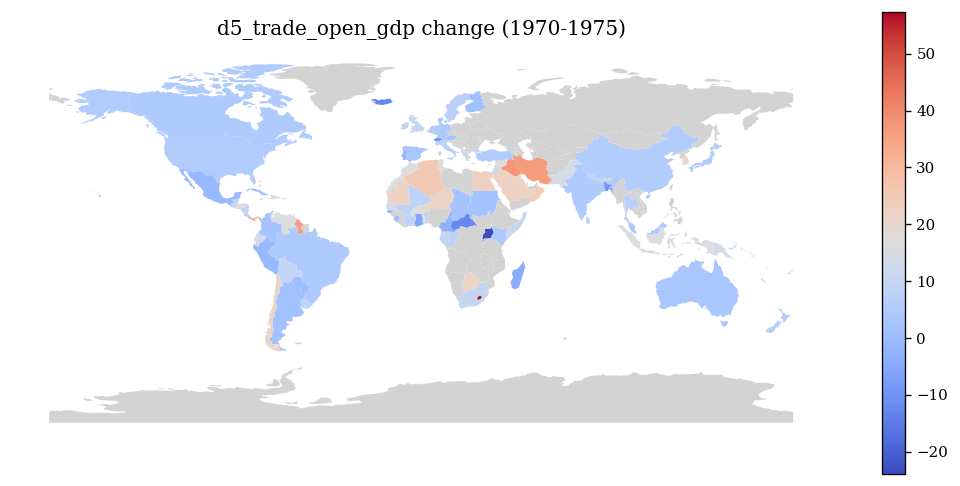

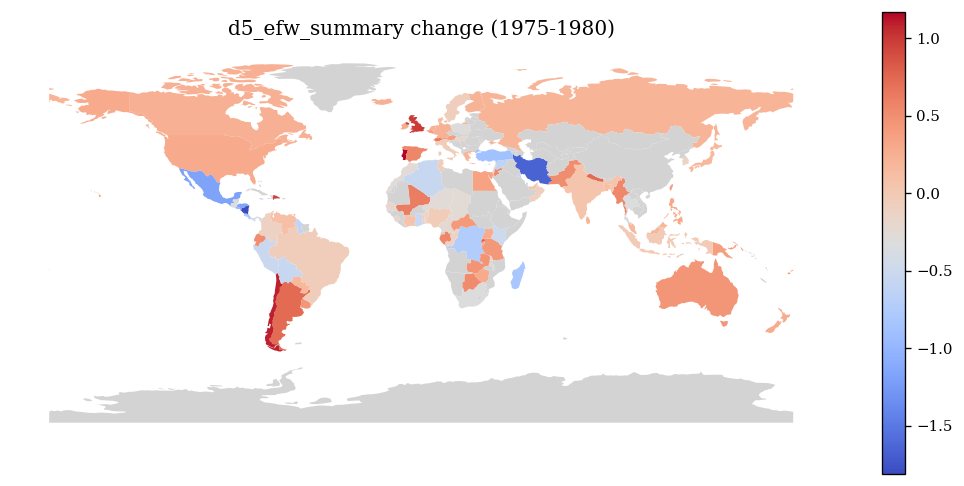

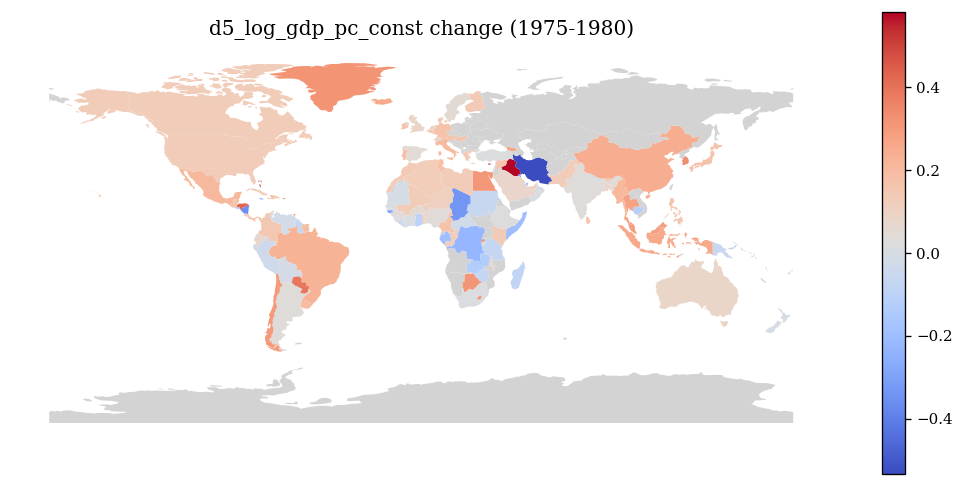

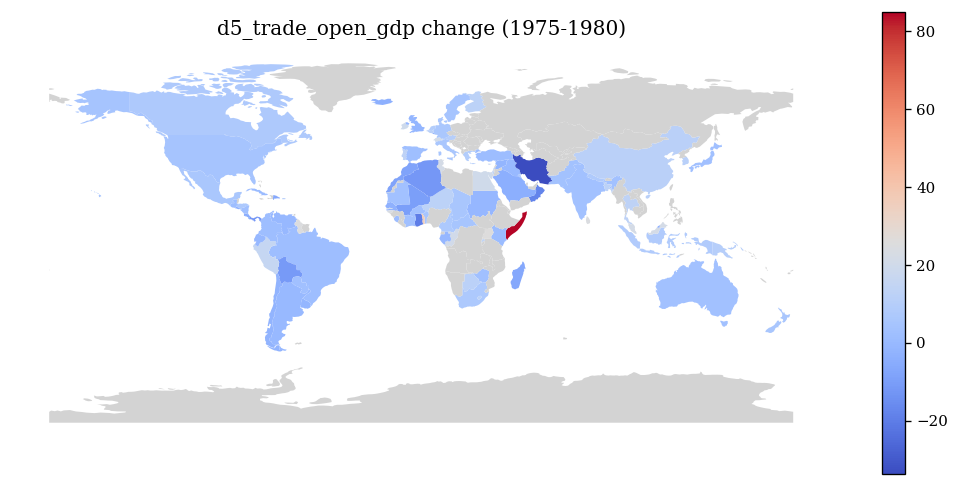

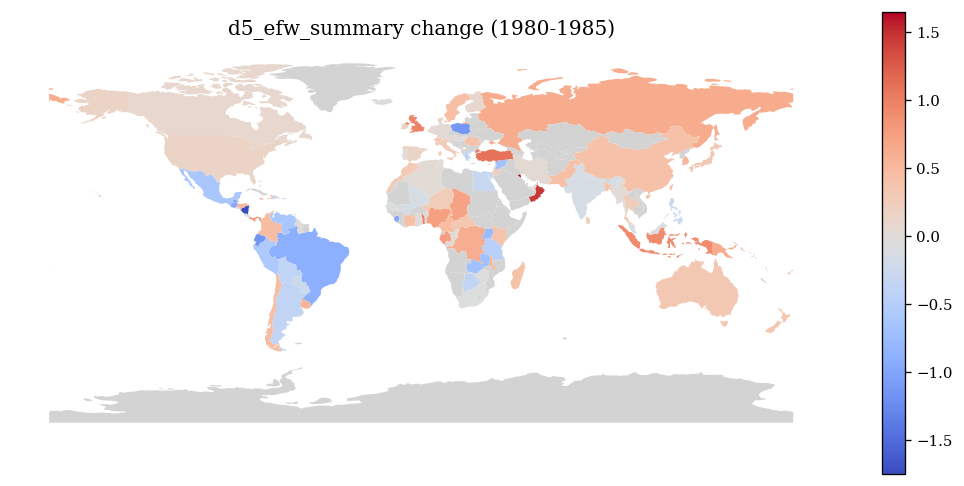

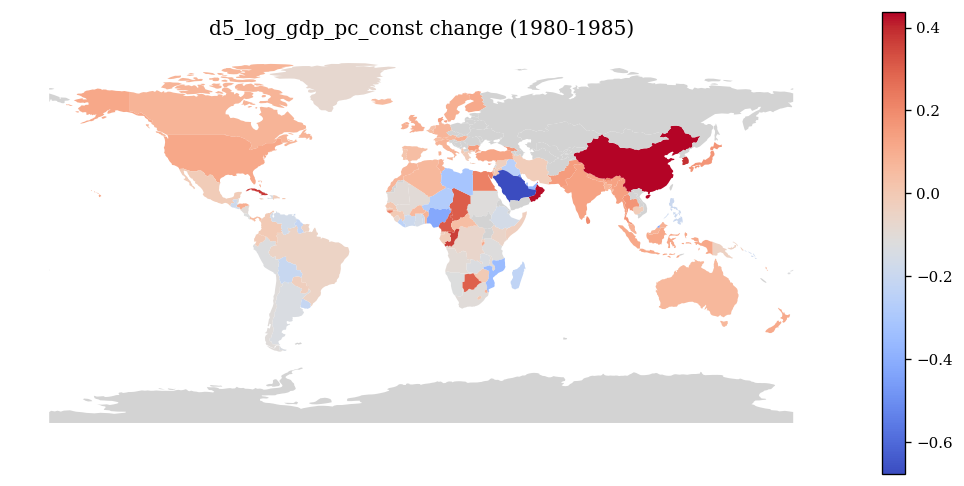

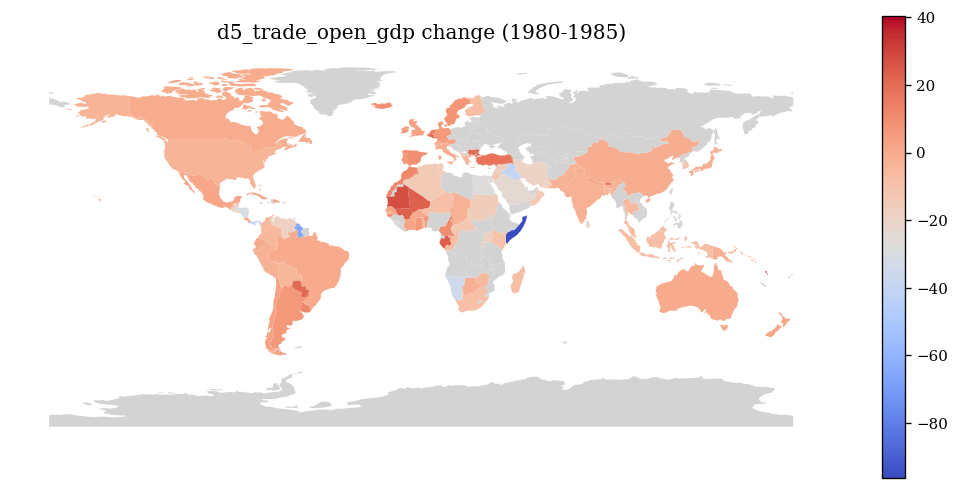

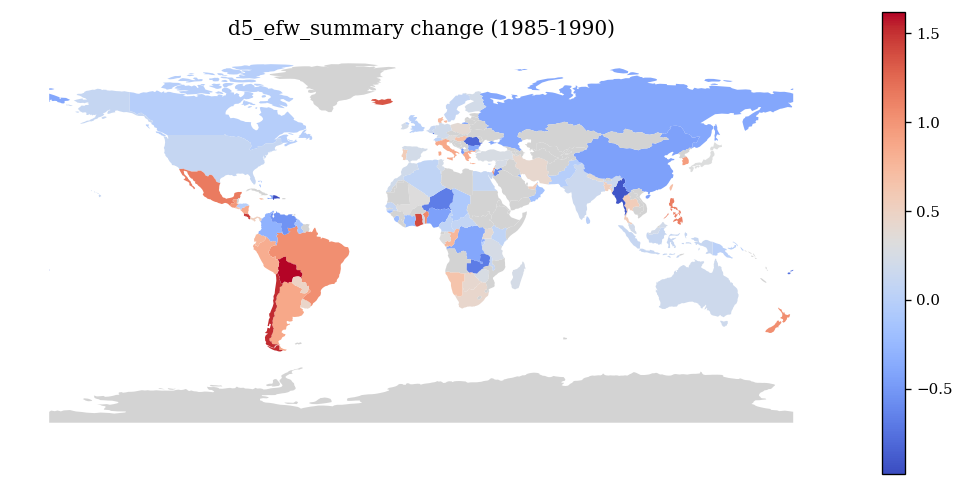

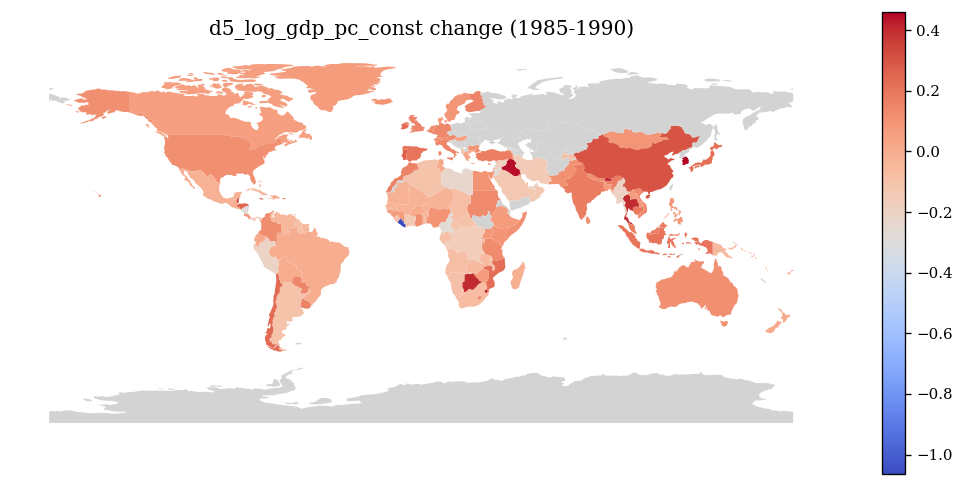

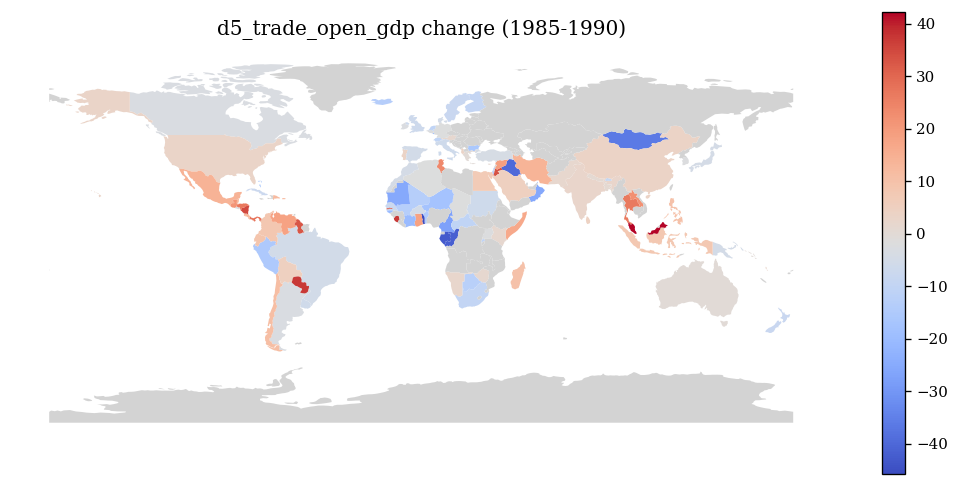

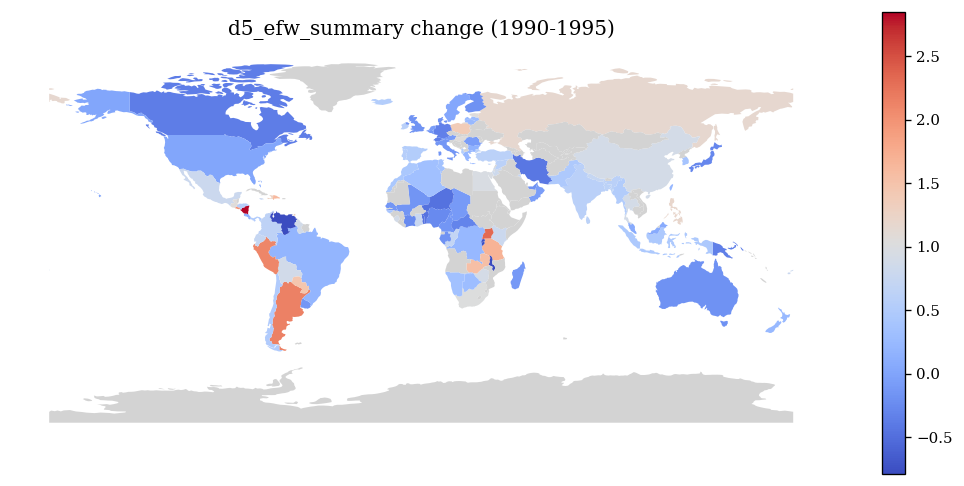

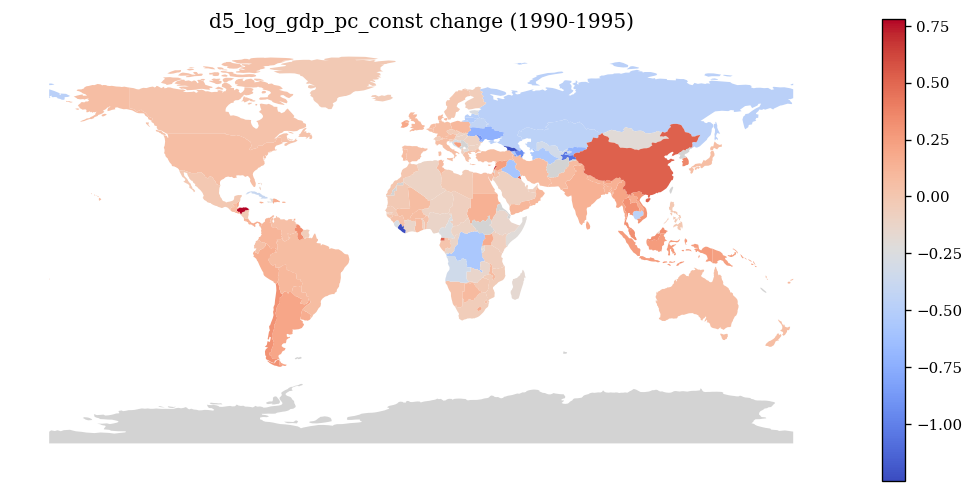

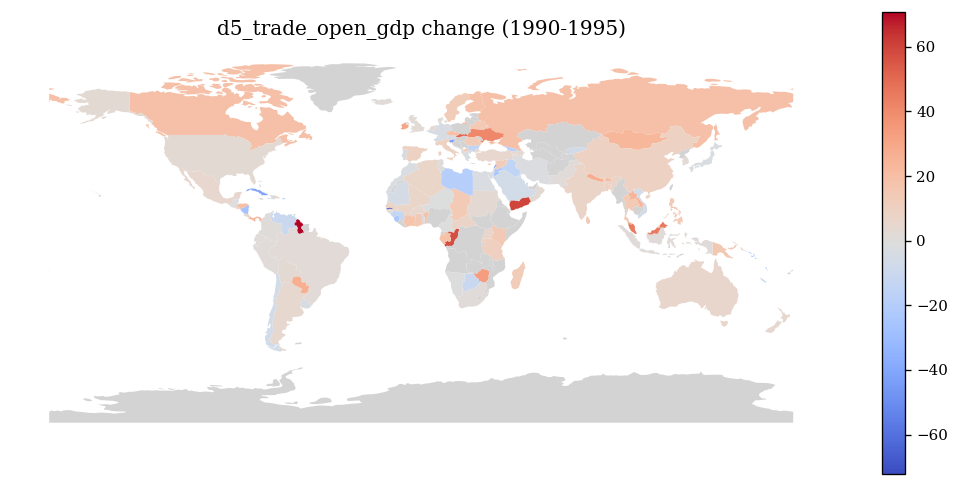

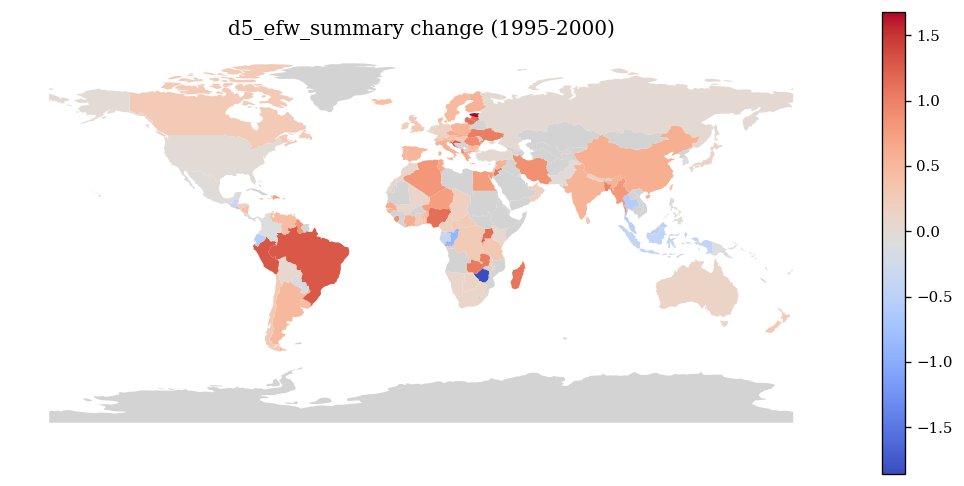

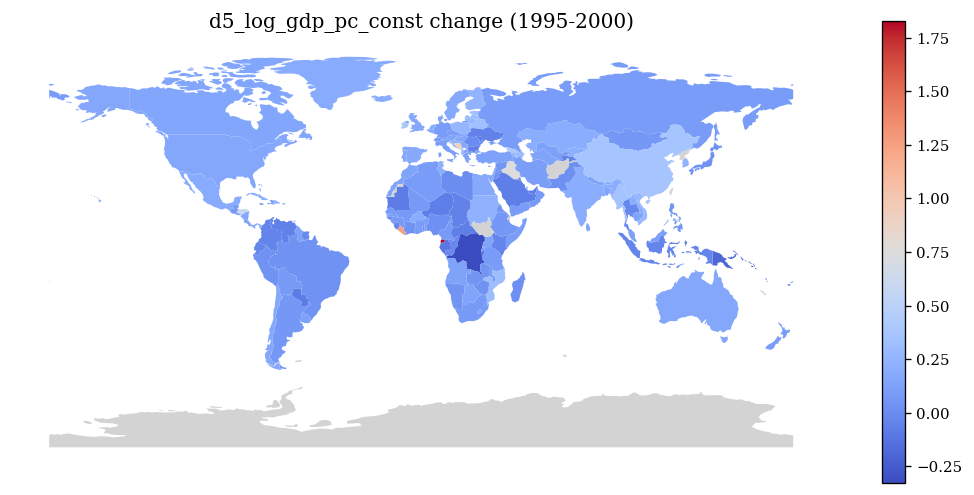

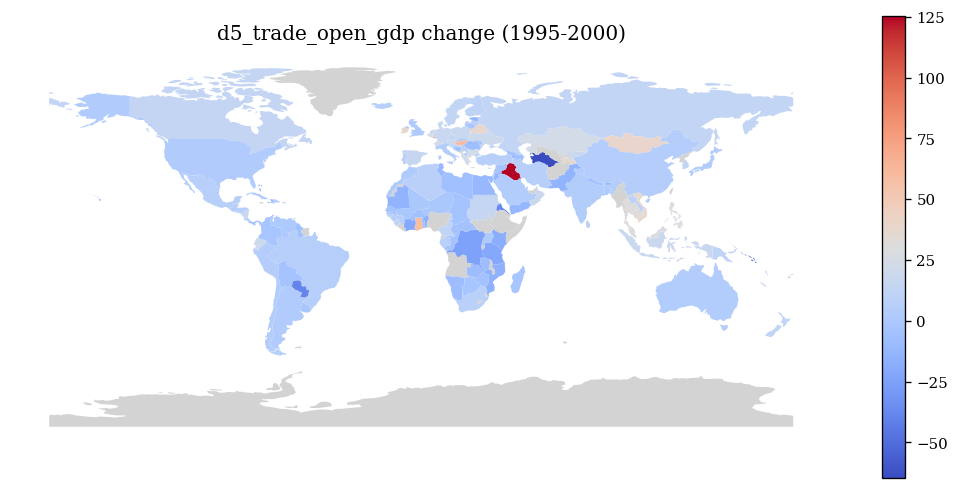

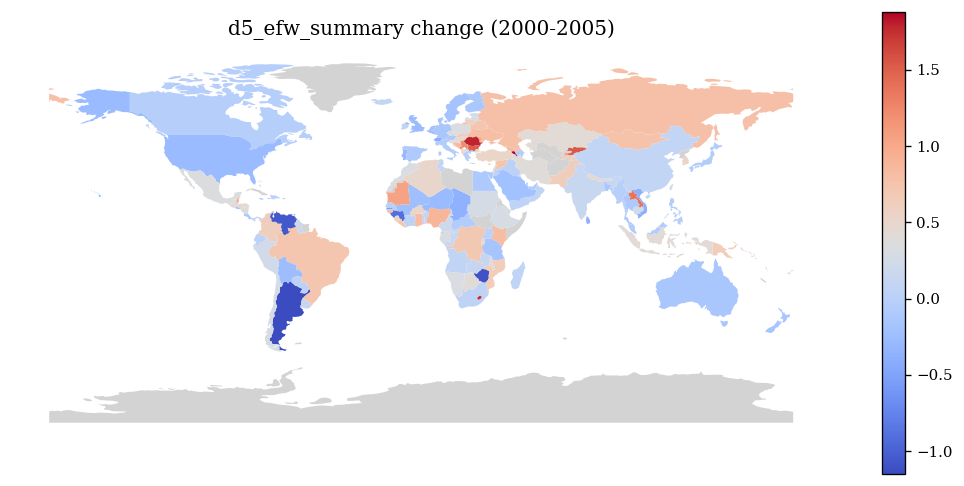

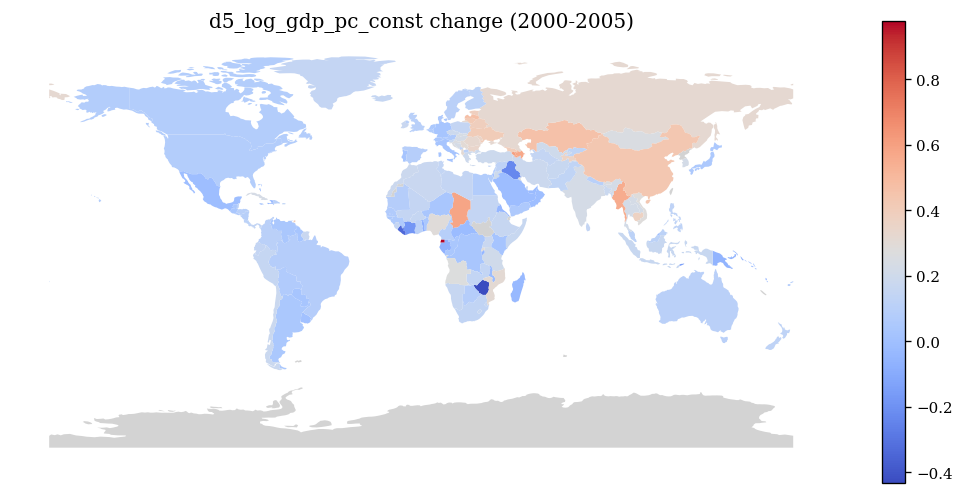

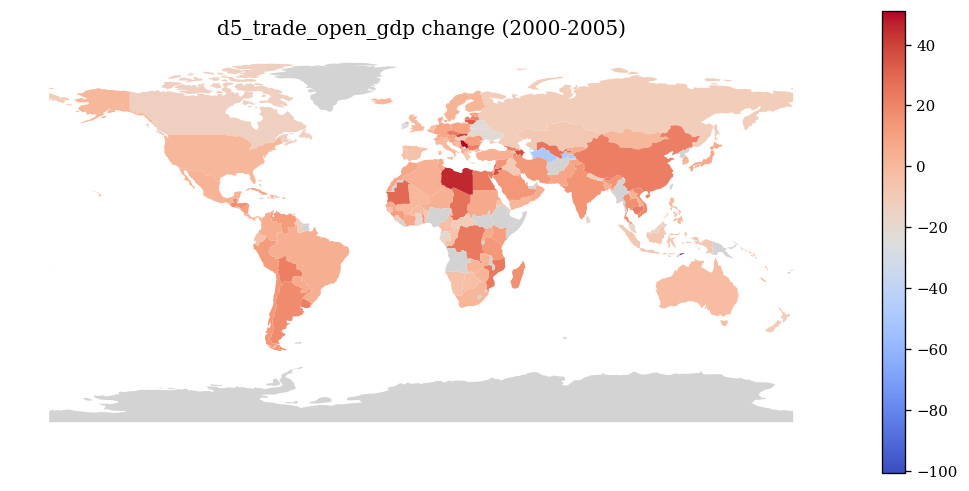

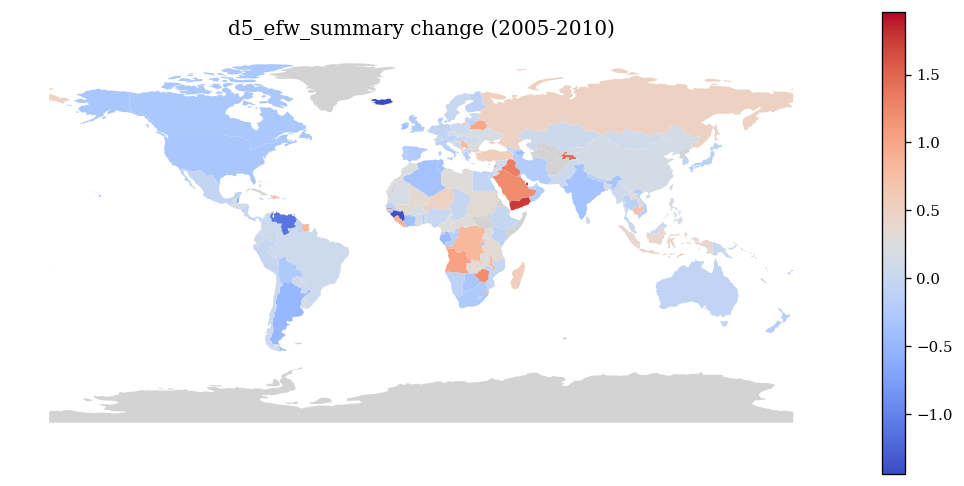

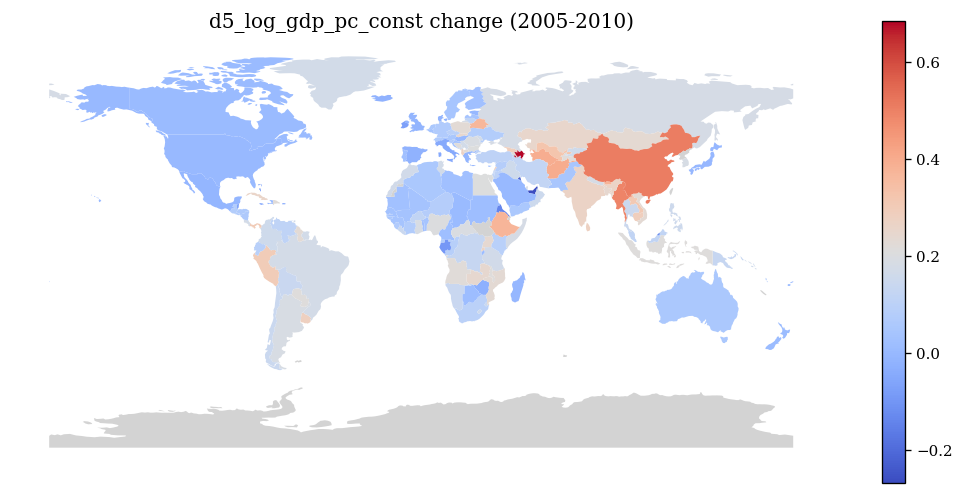

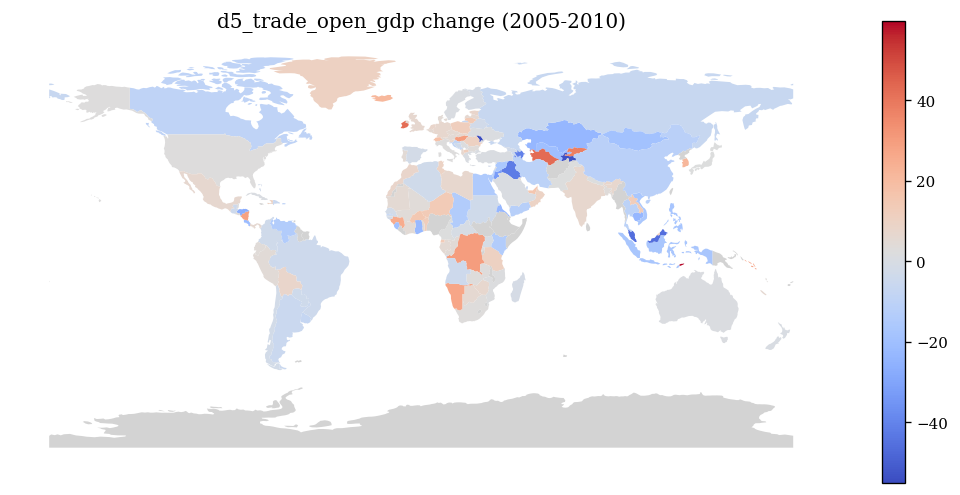

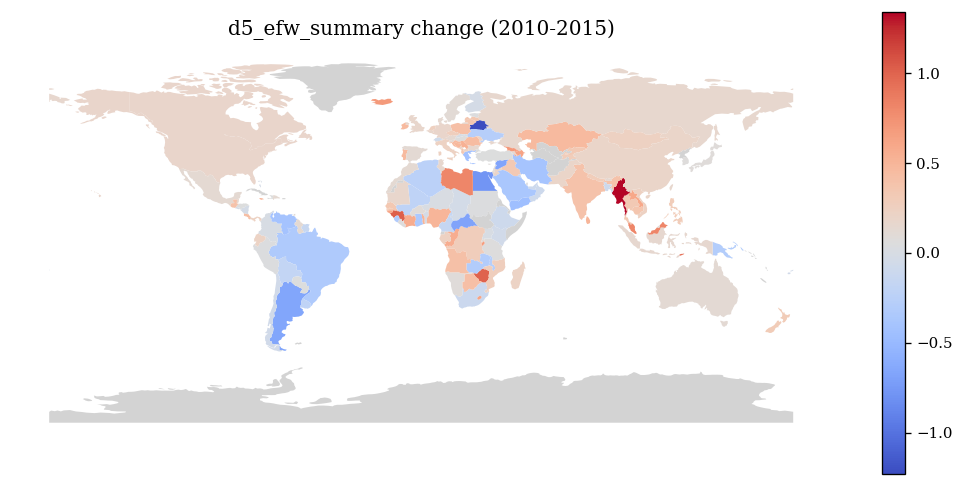

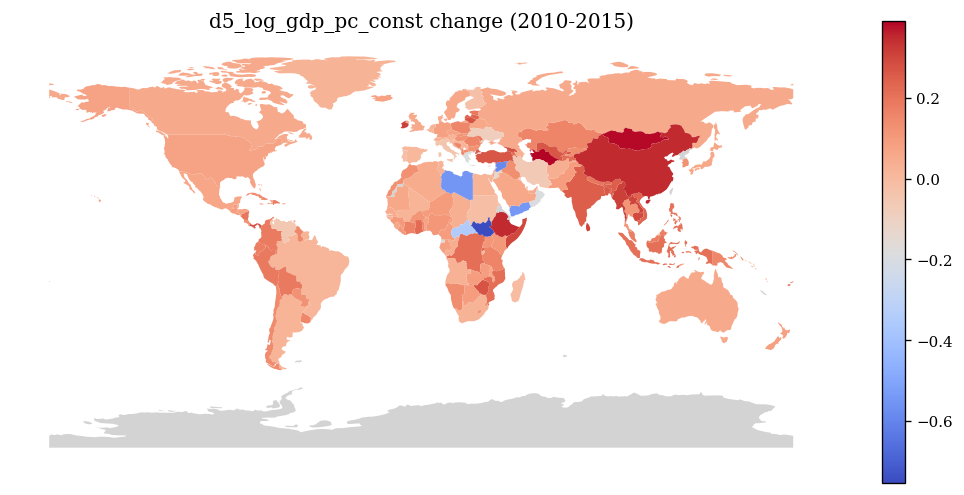

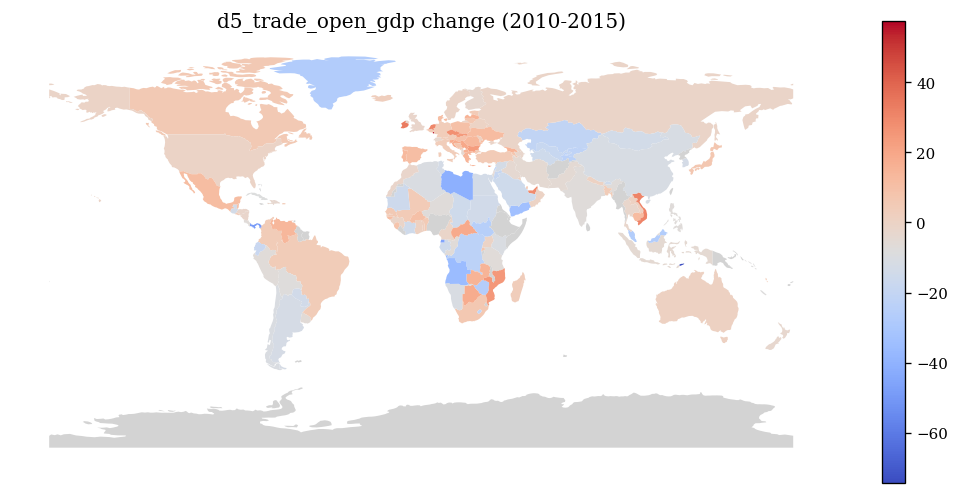

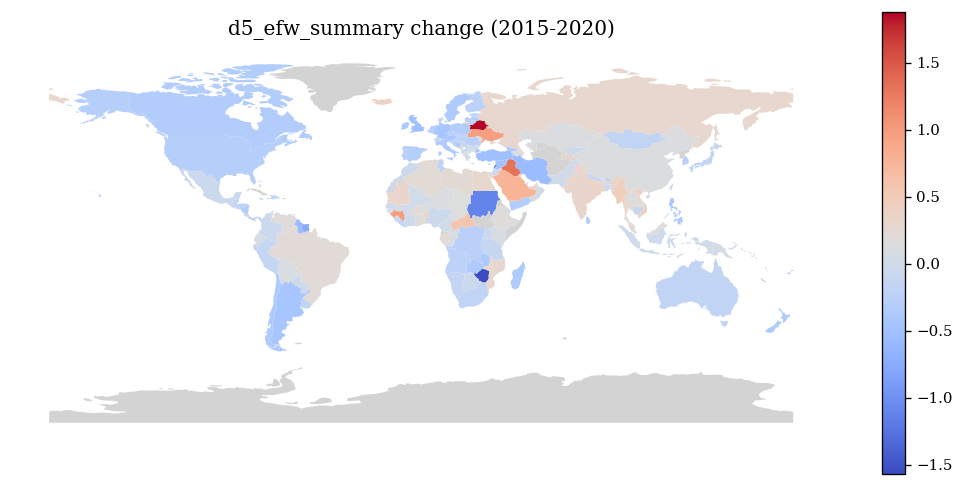

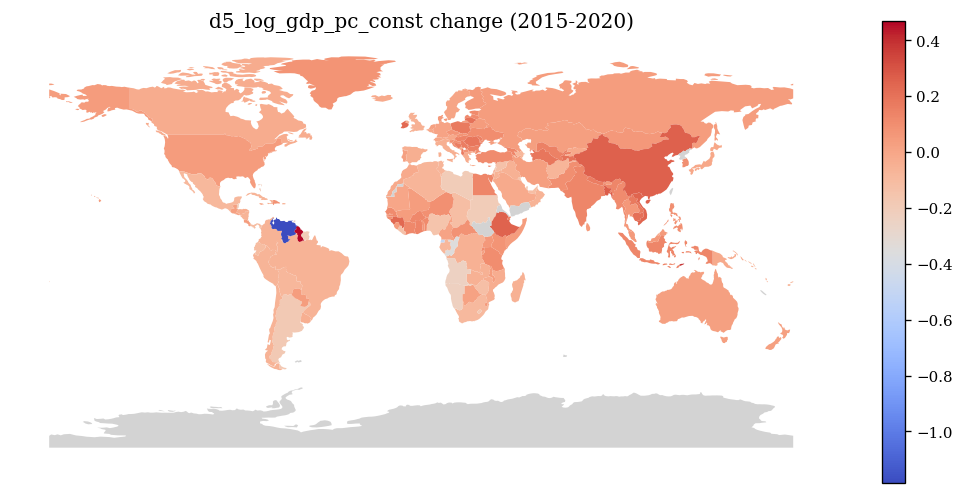

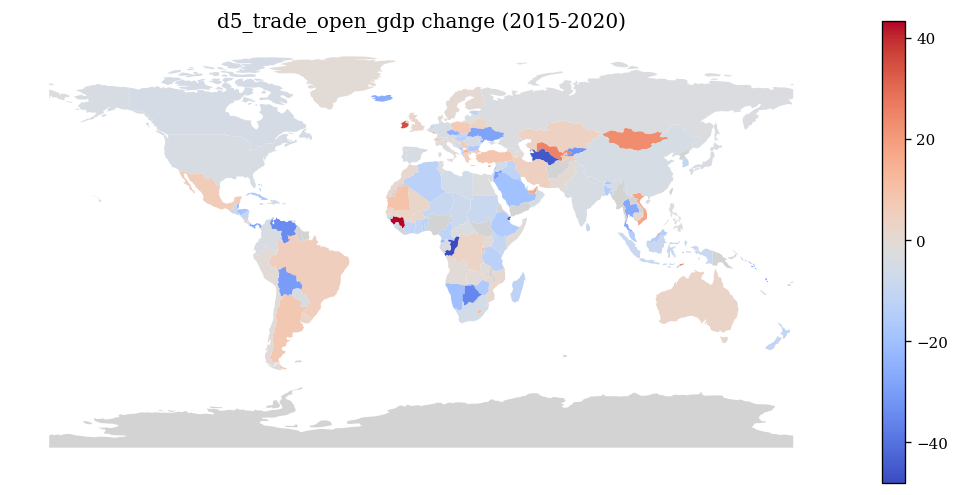

In [4]:
change_vars = ["d5_efw_summary", "d5_log_gdp_pc_const", "d5_trade_open_gdp"]
change_vars = [var for var in change_vars if var in panel.columns]

for year in QUINQUENNIAL_YEARS:
    if year == QUINQUENNIAL_YEARS[0]:
        continue
    subset = panel[panel["year"] == year]
    start_year = year - 5
    for var in change_vars:
        merged = merge_world_data(world, subset, "iso3c", var)
        fig, _ = plot_choropleth(
            merged,
            var,
            title=f"{var} change ({start_year}-{year})",
            cmap="coolwarm",
            missing_color="lightgrey",
        )
        display(fig)
        savefig(fig, map_dir / f"change_{var}_{start_year}_{year}")
        plt.close(fig)

## Interpretation
The level maps underscore persistent spatial clustering in economic freedom
and income levels, while the change maps highlight periods and regions of
notable improvement or decline. In 2020 the EFW summary spans a wide range
(about 2.98 to 8.64), reinforcing the cross-country dispersion visible in the
choropleths and in the summary table.